In [3]:
import xarray as xr
import numpy as np
import json

In [4]:
settings_file_path = "../v2_dpa_train_settings_post2000.json"

with open(settings_file_path, 'r') as file:
        settings = json.load(file)

# Load temperature data
ds = xr.open_dataset(settings['dataset_trefht'])
ds

<xarray.Dataset> Size: 788MB
Dimensions:  (lat: 32, lon: 32, time: 191900)
Coordinates:
  * lat      (lat) float64 256B 34.4 35.34 36.28 37.23 ... 61.73 62.67 63.61
  * lon      (lon) float64 256B -11.25 -10.0 -8.75 -7.5 ... 25.0 26.25 27.5
  * time     (time) object 2MB 2000-06-02 00:00:00 ... 2100-08-31 00:00:00
Data variables:
    TREFHT   (lat, lon, time) float32 786MB ...

In [6]:
ds_train = ds.isel(time=slice(0, 1919 * 90)) #4769 * 80
ds_test = ds.isel(time=slice(1919 * 90,1919900))
ds_train

<xarray.Dataset> Size: 709MB
Dimensions:  (lat: 32, lon: 32, time: 172710)
Coordinates:
  * lat      (lat) float64 256B 34.4 35.34 36.28 37.23 ... 61.73 62.67 63.61
  * lon      (lon) float64 256B -11.25 -10.0 -8.75 -7.5 ... 25.0 26.25 27.5
  * time     (time) object 1MB 2000-06-02 00:00:00 ... 2100-08-31 00:00:00
Data variables:
    TREFHT   (lat, lon, time) float32 707MB ...

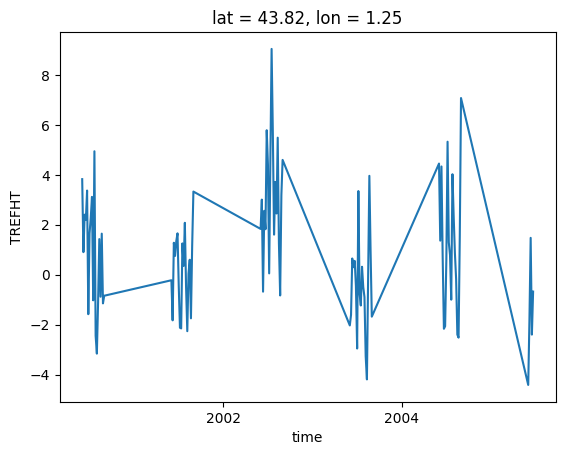

In [9]:
# plot timeseries

ds_train.TREFHT.isel(lat=10, lon=10, time = slice(0,100)).plot()

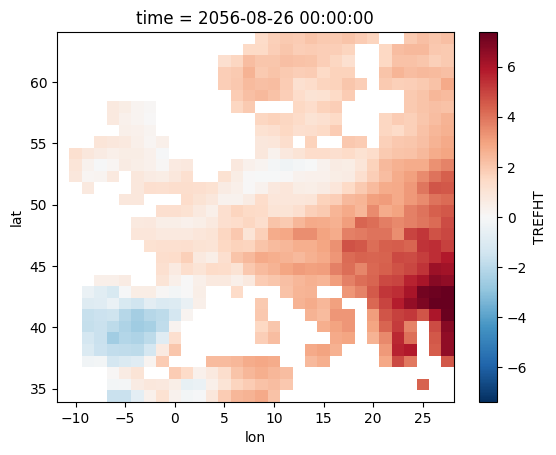

In [10]:
# plot map 

ds_train.TREFHT.isel(time = 3000).plot()